# Public TCR–pMHC datasets: exploration

Three public datasets sit under `Public_Datasets/`:

| Dataset | File used | Format |
|---|---|---|
| **McPAS-TCR** | `McPAS_TCR/McPAS-TCR_July1_2026.csv` | one row per TCR (paired α/β columns) |
| **VDJdb** | `VDJdb/.../vdjdb_full.txt` | one row per (reconstructed) TCR, paired α/β columns |
| **IEDB** | `IEDB_tcrpmhc/tcr_full_v3.csv` | one row per receptor, Chain 1 (α) / Chain 2 (β) |

For each we look at:
1. **How many records** it has.
2. **Distribution** of TCR–peptide–MHC records over metadata (antigen / source organism, healthy vs disease, species, MHC class).
3. **How many records are fully resolved** — i.e. have *all four* of: α-chain CDR3, β-chain CDR3, MHC allele, and epitope peptide. These are the records eligible for modeling.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

BASE = "Public_Datasets"
MCPAS = f"{BASE}/McPAS_TCR/McPAS-TCR_July1_2026.csv"
VDJDB = f"{BASE}/VDJdb/vdjdb-2026-06-03/vdjdb_full.txt"
IEDB  = f"{BASE}/IEDB_tcrpmhc/tcr_full_v3.csv"

def present(s):
    """Boolean mask: value is a real, non-empty string (not NaN / '' / 'nan')."""
    return s.notna() & s.astype(str).str.strip().replace({"nan": "", "NA": "", "None": ""}).str.len().gt(0)

def topbar(counts, title, xlabel, top=15, color="#4C72B0"):
    c = counts.head(top)[::-1]
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35*len(c)+1)))
    ax.barh(c.index.astype(str), c.values, color=color)
    ax.set_title(title); ax.set_xlabel(xlabel)
    for i, v in enumerate(c.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=8)
    fig.tight_layout(); plt.show()

summary = {}  # dataset -> dict of counts, filled in as we go


## 1. McPAS-TCR

Manually curated database of TCRs with known antigen specificity. Paired α/β CDR3 columns, plus a `Category` (Pathogens / Autoimmune / Cancer / Allergy) and a free-text `Pathology` that gives us the healthy-vs-disease axis.

In [4]:
mc = pd.read_csv(MCPAS, encoding="latin-1", low_memory=False)
print(f"McPAS-TCR: {len(mc):,} records, {mc.shape[1]} columns")
mc.head(3)


McPAS-TCR: 40,731 records, 29 columns


,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,ATSIRFTDTQYF,Human,Autoimmune,Celiac disease,D002503,6 days post oral gluten\nchallenge,1.0,Yes,Yes,...,TRAV8-6,NaN,TRBV7-2,NaN,TRBJ2-3,NaN,NaN,NaN,23878218,NaN
1,NaN,CAAAAASGAYEQYF,Human,Pathogens,M.Tuberculosis,D009169,Bulk,2.2,No,Yes,...,NaN,NaN,TRBV10-3,NaN,NaN,NaN,NaN,NaN,32341563,NaN
2,NaN,CAAADEEIGNQPQHF,Human,Pathogens,Hepatitis C virus,D016174,NaN,1.0,No,No,...,NaN,NaN,TRBV10-03,NaN,NaN,No,NaN,NaN,21160049,NaN


In [5]:
# metadata distributions
print("Species:\n", mc["Species"].value_counts(dropna=False), "\n")
print("Category (disease type):\n", mc["Category"].value_counts(dropna=False), "\n")
print("Top pathologies:\n", mc["Pathology"].value_counts().head(15))


Species:
 Species
Human    36474
Mouse     3701
NaN        556
Name: count, dtype: int64 

Category (disease type):
 Category
Pathogens     32011
Cancer         3880
Autoimmune     3744
NaN             513
Allergy         430
Other           153
Name: count, dtype: int64 

Top pathologies:
 Pathology
M.Tuberculosis                        16659
Influenza                              6048
Cytomegalovirus (CMV)                  2745
M. tuberculosis                        2116
Neoantigen                             1569
Epstein Barr virus (EBV)               1490
Diabetes Type 1                        1463
Human immunodeficiency virus (HIV)     1291
Melanoma                                773
ARDS                                    771
Celiac disease                          558
mCMV                                    529
Merkel cell carcinoma                   477
Yellow fever virus                      306
HTLV-1                                  277
Name: count, dtype: int64


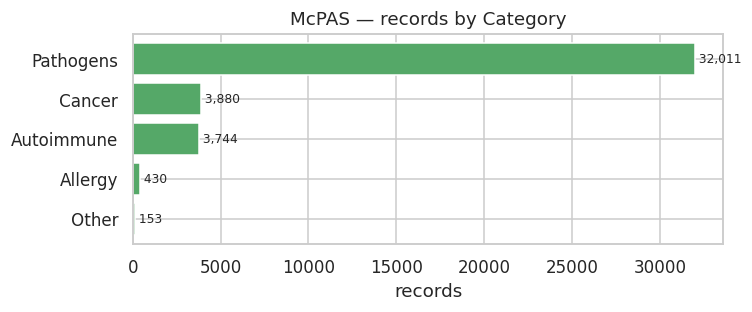

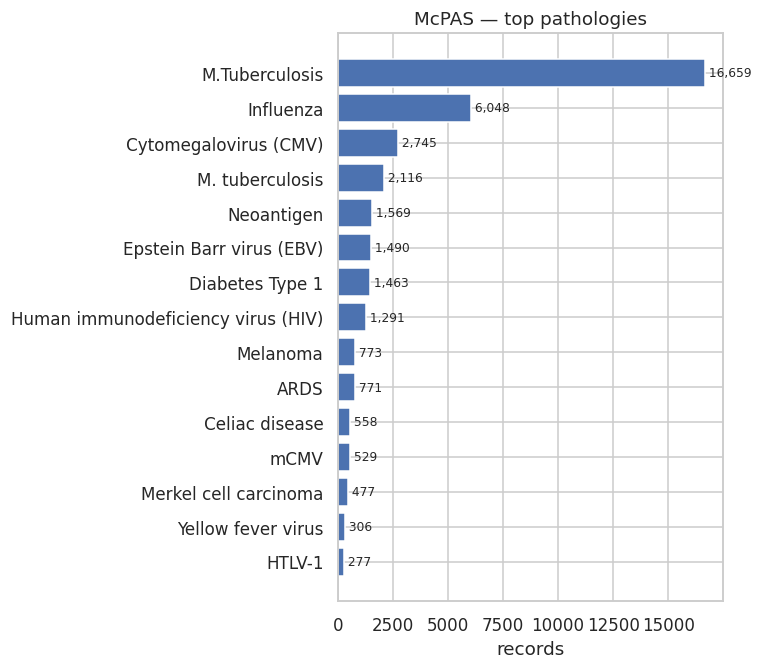

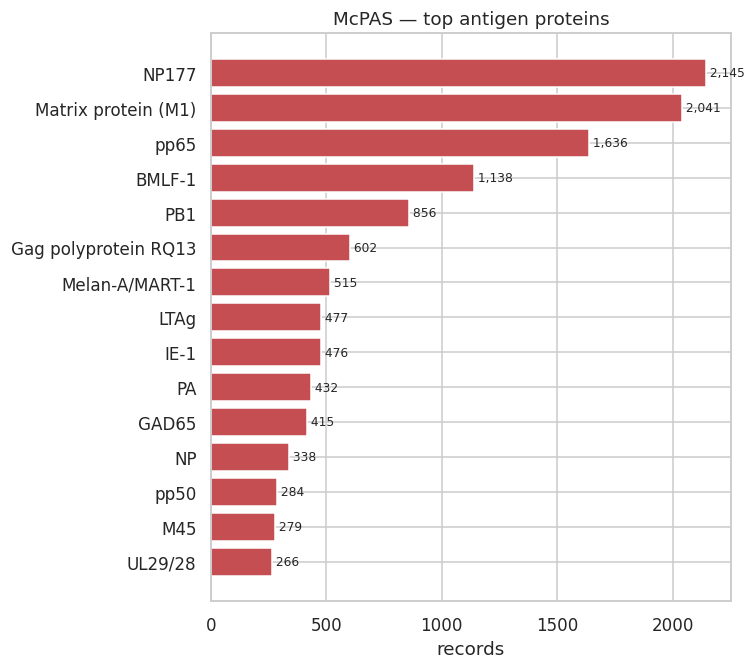

In [6]:
topbar(mc["Category"].value_counts(), "McPAS — records by Category", "records", color="#55A868")
topbar(mc["Pathology"].value_counts(), "McPAS — top pathologies", "records")
topbar(mc["Antigen.protein"].value_counts(), "McPAS — top antigen proteins", "records", color="#C44E52")


In [22]:
# fully-resolved: alpha CDR3 + beta CDR3 + MHC + epitope peptide
mc_alpha = present(mc["CDR3.alpha.aa"])
mc_beta  = present(mc["CDR3.beta.aa"])
mc_mhc   = present(mc["MHC"])
mc_epi   = present(mc["Epitope.peptide"])
tcr_full = mc_alpha & mc_beta & present(mc['TRAJ']) & present(mc['TRBJ']) & present(mc['TRAV']) & present(mc['TRBV'])
mc_full  = tcr_full & mc_mhc & mc_epi

summary["McPAS-TCR"] = {
    "total": len(mc),
    "has_alpha": int(mc_alpha.sum()),
    "has_beta": int(mc_beta.sum()),
    "has_both_chains": int((mc_alpha & mc_beta).sum()),
    "has_mhc": int(mc_mhc.sum()),
    "has_epitope": int(mc_epi.sum()),
    "fully_resolved": int(mc_full.sum()),
}
pd.Series(summary["McPAS-TCR"])


total              40731
has_alpha          14702
has_beta           38360
has_both_chains    12732
has_mhc            17154
has_epitope        16711
fully_resolved      3117
dtype: int64

In [23]:
mc_full_df = mc.loc[mc_full]
mc_full_df.head(3)

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
12,CAVDNTDKLIF,CAAGSYEQYF,Human,Cancer,Tumor associated antigen (TAA),D018290,NaN,1.0,Yes,Yes,...,TRAV12-1,TRAJ34,TRBV6-5,NaN,TRBJ2-7,NaN,NaN,NaN,33562731,NaN
41,CAMREPNTEGADRLTF,CAAWGENYAEQFF,Mouse,Pathogens,Influenza,D009980,NaN,1.0,Yes,Yes,...,TRAV16D/DV11:01,TRAJ4-01,TRBV2-01,NaN,TRBJ2-1:01,No,NaN,C57/BL6,28636592,NaN
48,CAVSSNNRIFF,CACGGADSAETLYF,Mouse,Pathogens,Influenza,D009980,NaN,1.0,Yes,Yes,...,TRAV3-3:01,TRAJ3-01,TRBV1-01,NaN,TRBJ2-3:01,No,NaN,C57/BL6,28636592,NaN


In [29]:
mc_full_df_human = mc_full_df.loc[mc_full_df["Species"] == "Human"]

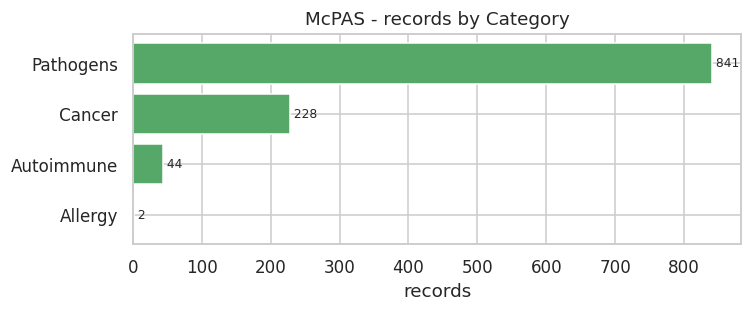

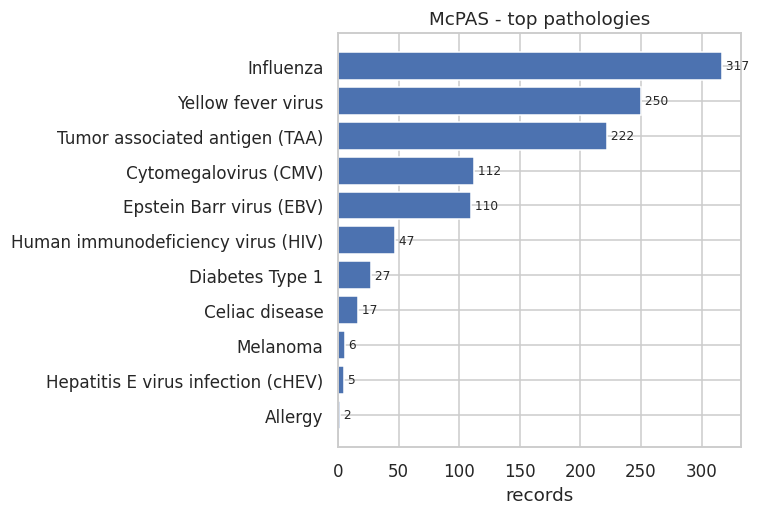

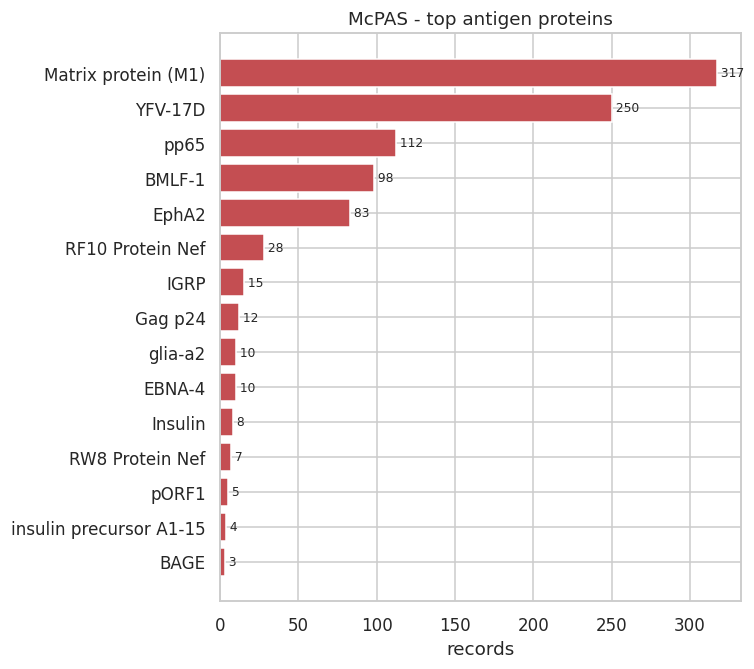

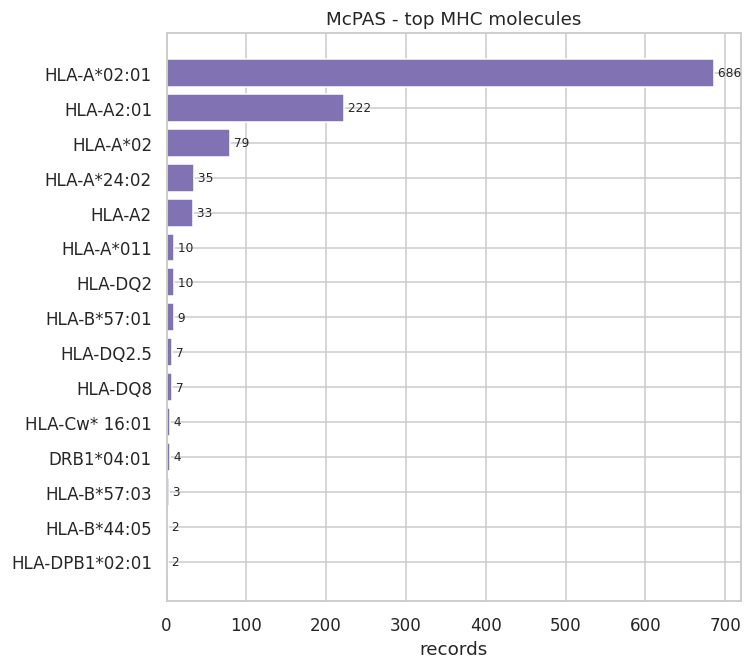

In [30]:
topbar(mc_full_df_human["Category"].value_counts(), "McPAS - records by Category", "records", color="#55A868")
topbar(mc_full_df_human["Pathology"].value_counts(), "McPAS - top pathologies", "records")
topbar(mc_full_df_human["Antigen.protein"].value_counts(), "McPAS - top antigen proteins", "records", color="#C44E52")
topbar(mc_full_df_human["MHC"].value_counts(), "McPAS - top MHC molecules", "records", color="#8172B3")


## 2. VDJdb

`vdjdb_full.txt` is the paired reconstruction (one row per TCR with `cdr3.alpha` / `cdr3.beta` columns). Metadata includes `antigen.species`, `antigen.gene`, `mhc.class`, host `species`, and a free-text `meta.subject.cohort` that sometimes records healthy vs patient cohorts.

In [31]:
vd = pd.read_csv(VDJDB, sep="\t", low_memory=False)
print(f"VDJdb (vdjdb_full): {len(vd):,} records, {vd.shape[1]} columns")
vd.head(3)


VDJdb (vdjdb_full): 192,753 records, 35 columns


,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,mhc.b,...,meta.clone.id,meta.epitope.id,meta.tissue,meta.donor.MHC,meta.donor.MHC.method,meta.structure.id,cdr3fix.alpha,cdr3fix.beta,vdjdb.score,TCR_hash
0,NaN,NaN,NaN,CASSIVGGNEQFF,TRBV19*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIVGGNEQFF', 'cdr3_old': 'CASSIVG...",3,NaN
1,NaN,NaN,NaN,CASSMRSTGELFF,TRBV19*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSMRSTGELFF', 'cdr3_old': 'CASSMRS...",3,NaN
2,NaN,NaN,NaN,CASSIRSAWAQYF,TRBV19*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,M158–66,PBMC,"A02,A03,B07,B27,C01,C07",NaN,NaN,NaN,"{'cdr3': 'CASSIRSAWAQYF', 'cdr3_old': 'CASSIRS...",2,NaN


In [32]:
vd.columns = vd.columns.str.strip()  # remove whitespace from column names
print(vd.columns.tolist())

['cdr3.alpha', 'v.alpha', 'j.alpha', 'cdr3.beta', 'v.beta', 'd.beta', 'j.beta', 'species', 'mhc.a', 'mhc.b', 'mhc.class', 'antigen.epitope', 'antigen.gene', 'antigen.species', 'reference.id', 'method.identification', 'method.frequency', 'method.singlecell', 'method.sequencing', 'method.verification', 'meta.study.id', 'meta.cell.subset', 'meta.subject.cohort', 'meta.subject.id', 'meta.replica.id', 'meta.clone.id', 'meta.epitope.id', 'meta.tissue', 'meta.donor.MHC', 'meta.donor.MHC.method', 'meta.structure.id', 'cdr3fix.alpha', 'cdr3fix.beta', 'vdjdb.score', 'TCR_hash']


In [33]:
print("Host species:\n", vd["species"].value_counts(dropna=False), "\n")
print("MHC class:\n", vd["mhc.class"].value_counts(dropna=False), "\n")
print("Top antigen source species:\n", vd["antigen.species"].value_counts().head(15))


Host species:
 species
HomoSapiens      176130
MusMusculus       14852
MacacaMulatta      1771
Name: count, dtype: int64 

MHC class:
 mhc.class
MHCI     178463
MHCII     14290
Name: count, dtype: int64 

Top antigen source species:
 antigen.species
HomoSapiens       53634
CMV               41512
EBV               39048
InfluenzaA        23005
SARS-CoV-2        12551
HIV-1              3938
HBV                2818
YFV                2446
M.tuberculosis     2295
MusMusculus        2161
SIV                1771
HCV                1743
MCMV               1183
LCMV                653
HTLV-1              548
Name: count, dtype: int64


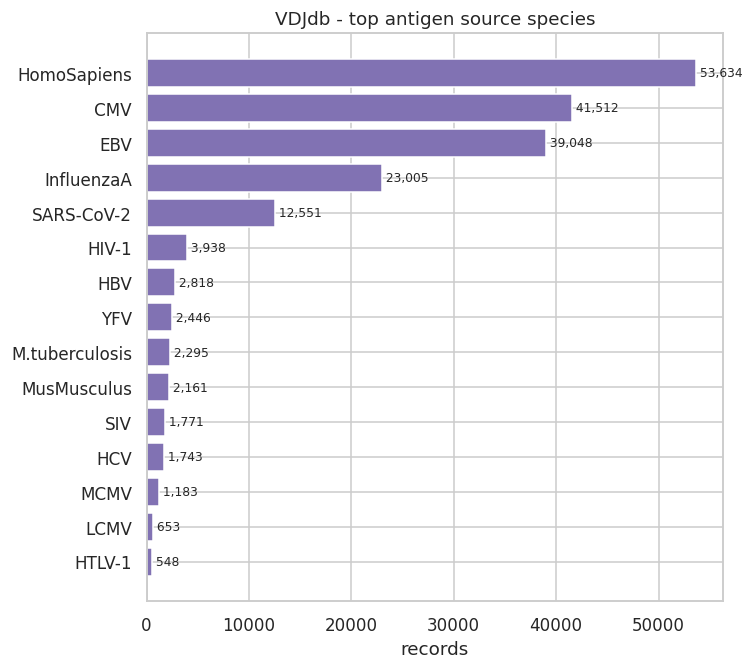

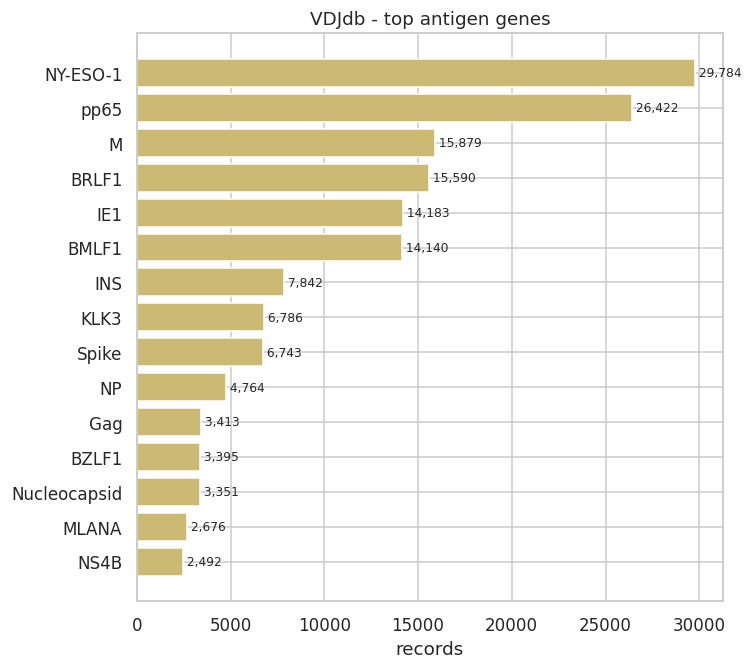

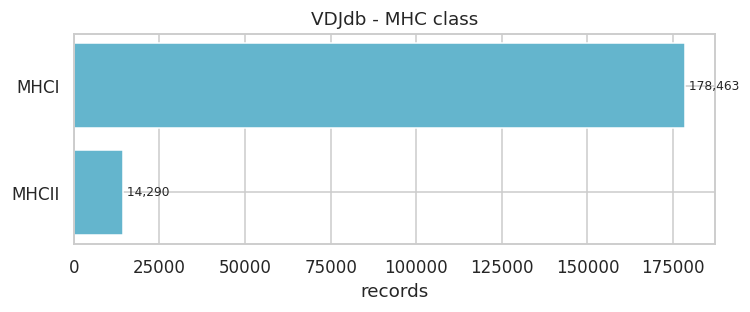

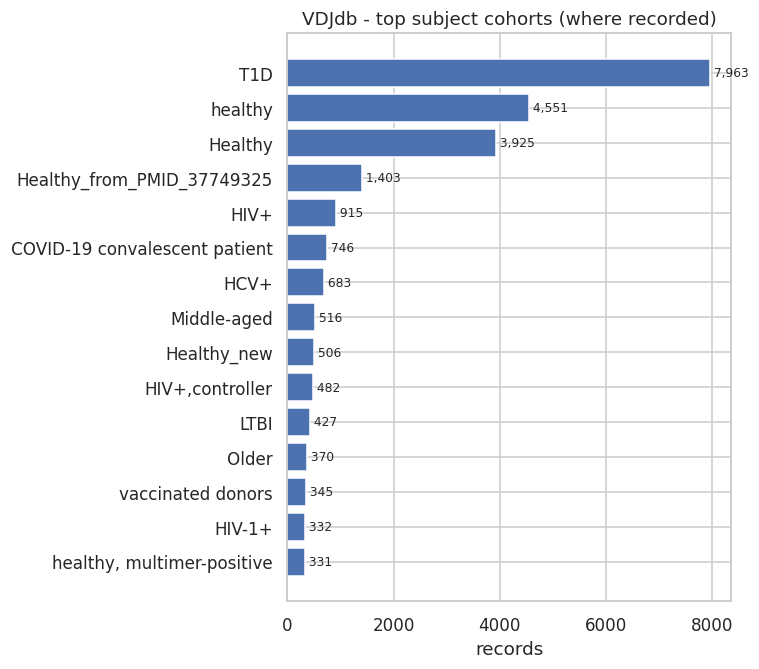

In [34]:
topbar(vd["antigen.species"].value_counts(), "VDJdb - top antigen source species", "records", color="#8172B3")
topbar(vd["antigen.gene"].value_counts(), "VDJdb - top antigen genes", "records", color="#CCB974")
topbar(vd["mhc.class"].value_counts(), "VDJdb - MHC class", "records", color="#64B5CD")
# subject cohort is free-text; show the populated ones
coh = vd["meta.subject.cohort"].replace("", np.nan).dropna()
if len(coh):
    topbar(coh.value_counts(), "VDJdb - top subject cohorts (where recorded)", "records")


In [ ]:
vd_alpha = present(vd["cdr3.alpha"])
vd_beta  = present(vd["cdr3.beta"])
vd_mhc   = present(vd["mhc.a"])
vd_epi   = present(vd["antigen.epitope"])
#vd_full  = vd_alpha & vd_beta & vd_mhc & vd_epi
tcr_full = vd_alpha & vd_beta & present(vd['j.alpha']) & present(vd['j.beta']) & present(vd['v.alpha']) & present(vd['v.beta'])
vd_full  = tcr_full & vd_mhc & vd_epi

summary["VDJdb"] = {
    "total": len(vd),
    "has_alpha": int(vd_alpha.sum()),
    "has_beta": int(vd_beta.sum()),
    "has_both_chains": int((vd_alpha & vd_beta).sum()),
    "has_mhc": int(vd_mhc.sum()),
    "has_epitope": int(vd_epi.sum()),
    "fully_resolved": int(vd_full.sum()),
}
pd.Series(summary["VDJdb"])


total              192753
has_alpha          122930
has_beta           163083
has_both_chains     93260
has_mhc            192753
has_epitope        192753
fully_resolved      93260
dtype: int64

## 3. IEDB (tcr_full_v3)

Two-row header. Chain 1 is the α-chain, Chain 2 the β-chain. CDR3 comes in `Curated` and `Calculated` flavours — a chain counts as resolved if *either* is present. MHC is `Assay | MHC Allele Names`, epitope is `Epitope | Name`, and `Epitope | Source Organism` is our antigen axis. There is no explicit healthy/disease column here.

In [12]:
ie = pd.read_csv(IEDB, header=[0, 1], low_memory=False)
ie.columns = ["|".join([str(a), str(b)]) for a, b in ie.columns]
print(f"IEDB tcr_full_v3: {len(ie):,} records, {ie.shape[1]} columns")

# a chain's CDR3 = curated OR calculated
ie_a_cdr3 = present(ie["Chain 1|CDR3 Curated"]) | present(ie["Chain 1|CDR3 Calculated"])
ie_b_cdr3 = present(ie["Chain 2|CDR3 Curated"]) | present(ie["Chain 2|CDR3 Calculated"])
ie.head(3)


IEDB tcr_full_v3: 299,756 records, 74 columns


,Receptor|Group IRI,Receptor|IEDB Receptor ID,Receptor|Reference Name,Receptor|Type,Reference|IEDB IRI,Epitope|IEDB IRI,Epitope|Name,Epitope|Source Molecule,Epitope|Source Organism,Assay|Type,...,Chain 2|CDR1 End Curated,Chain 2|CDR1 Start Calculated,Chain 2|CDR1 End Calculated,Chain 2|CDR2 Curated,Chain 2|CDR2 Calculated,Chain 2|CDR2 Start Curated,Chain 2|CDR2 End Curated,Chain 2|CDR2 Start Calculated,Chain 2|CDR2 End Calculated,Chain 2|V Domain Calculated
0,https://www.iedb.org/receptor/47,57,KK50.4,alphabeta,https://www.iedb.org/reference/1004539,https://www.iedb.org/epitope/69921,VMAPRTLIL,"HLA class I histocompatibility antigen, Cw-3 a...",Homo sapiens (human),T cell,...,NaN,NaN,NaN,NaN,FVKESK,NaN,NaN,NaN,NaN,GVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGKEIKFLLH...
1,https://www.iedb.org/receptor/49,69,"172.10, 172.10 TCR",alphabeta,https://www.iedb.org/reference/1005006,https://www.iedb.org/epitope/89042,SRGGASQYRPSQ,NaN,NaN,T cell,...,NaN,NaN,NaN,NaN,SYGAGS,NaN,NaN,NaN,NaN,AVTQSPRNKVAVTGEKVTLSCNQTNNHNNMYWYRQDTGHGLRLIYY...
2,https://www.iedb.org/receptor/49,69,"172.10, 172.10 TCR",alphabeta,https://www.iedb.org/reference/1005006,https://www.iedb.org/epitope/128330,ASQKRPSQRH + ACET(A1),Myelin basic protein S,Rattus norvegicus (brown rat),T cell,...,NaN,NaN,NaN,NaN,SYGAGS,NaN,NaN,NaN,NaN,AVTQSPRNKVAVTGEKVTLSCNQTNNHNNMYWYRQDTGHGLRLIYY...


In [13]:
print("Chain 1 types:\n", ie["Chain 1|Type"].value_counts(dropna=False), "\n")
print("Chain 2 types:\n", ie["Chain 2|Type"].value_counts(dropna=False), "\n")
print("Top epitope source organisms:\n", ie["Epitope|Source Organism"].value_counts().head(15))


Chain 1 types:
 Chain 1|Type
NaN          203766
alpha         95335
gamma           647
construct         5
delta             2
beta              1
Name: count, dtype: int64 

Chain 2 types:
 Chain 2|Type
beta         237814
NaN           59816
delta          2119
construct         5
gamma             2
Name: count, dtype: int64 

Top epitope source organisms:
 Epitope|Source Organism
SARS-CoV2                                                                                155877
Human herpesvirus 4 (Epstein Barr virus)                                                  52034
Human herpesvirus 5 (Human cytomegalovirus)                                               26452
Influenza A virus                                                                         20515
Homo sapiens (human)                                                                      13171
Hepatitis B virus (Human hepatitis B virus)                                                4561
Yellow fever virus (Flavivirus febr

/tmp/ipykernel_575462/3466776766.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(); plt.show()


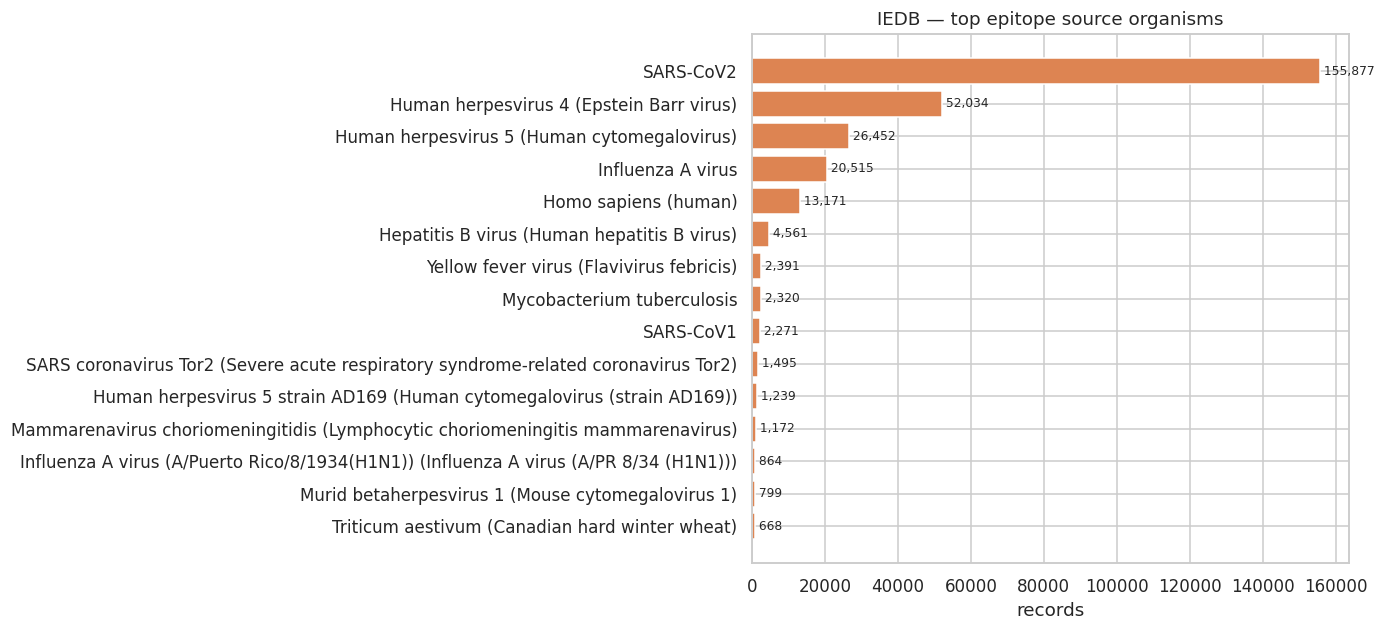

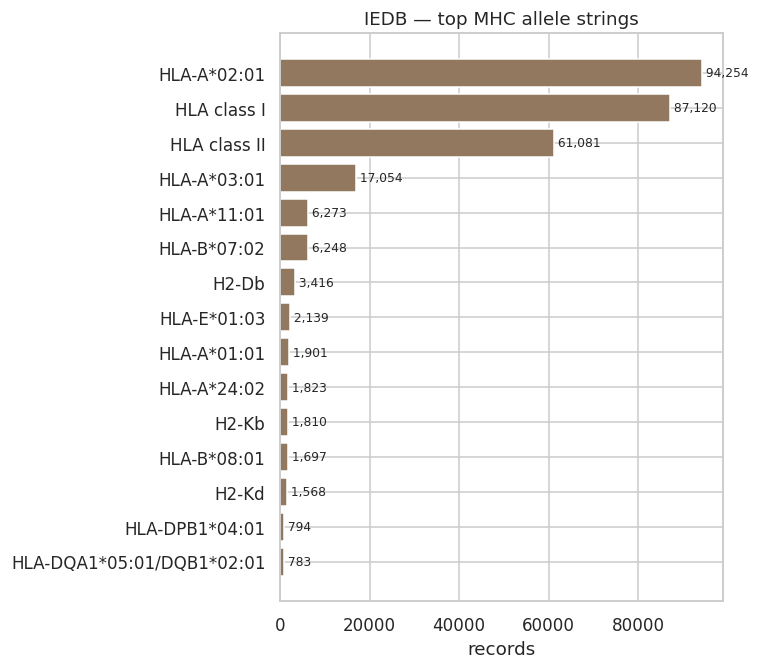

In [14]:
topbar(ie["Epitope|Source Organism"].value_counts(), "IEDB — top epitope source organisms", "records", color="#DD8452")
topbar(ie["Assay|MHC Allele Names"].value_counts(), "IEDB — top MHC allele strings", "records", color="#937860")


In [15]:
ie_mhc = present(ie["Assay|MHC Allele Names"])
ie_epi = present(ie["Epitope|Name"])
ie_full = ie_a_cdr3 & ie_b_cdr3 & ie_mhc & ie_epi

summary["IEDB"] = {
    "total": len(ie),
    "has_alpha": int(ie_a_cdr3.sum()),
    "has_beta": int(ie_b_cdr3.sum()),
    "has_both_chains": int((ie_a_cdr3 & ie_b_cdr3).sum()),
    "has_mhc": int(ie_mhc.sum()),
    "has_epitope": int(ie_epi.sum()),
    "fully_resolved": int(ie_full.sum()),
}
pd.Series(summary["IEDB"])


total              299756
has_alpha           95919
has_beta           239647
has_both_chains     36082
has_mhc            298792
has_epitope        299756
fully_resolved      35995
dtype: int64

## 4. Summary — records eligible for modeling

**Fully resolved** = has α-chain CDR3 **and** β-chain CDR3 **and** MHC allele **and** epitope peptide. Only these enter the model.

In [16]:
summ = pd.DataFrame(summary).T[
    ["total", "has_alpha", "has_beta", "has_both_chains", "has_mhc", "has_epitope", "fully_resolved"]
]
summ["pct_fully_resolved"] = (100 * summ["fully_resolved"] / summ["total"]).round(1)
summ


,total,has_alpha,has_beta,has_both_chains,has_mhc,has_epitope,fully_resolved,pct_fully_resolved
McPAS-TCR,40731,14702,38360,12732,17154,16711,5014,12.3
VDJdb,192753,122930,163083,93260,192753,192753,93260,48.4
IEDB,299756,95919,239647,36082,298792,299756,35995,12.0


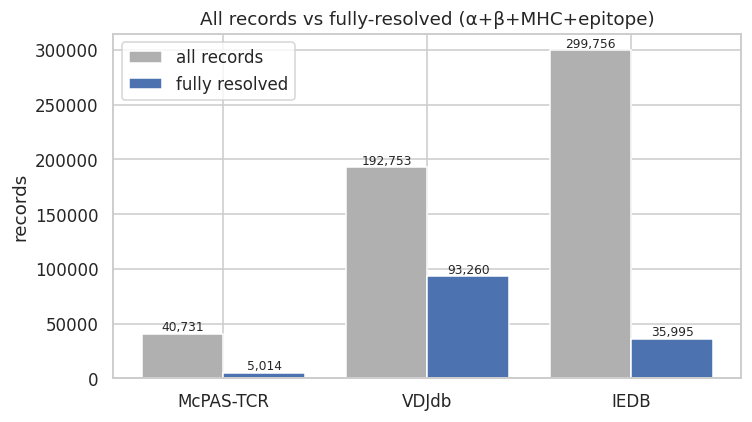

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(summ))
ax.bar(x - 0.2, summ["total"], width=0.4, label="all records", color="#B0B0B0")
ax.bar(x + 0.2, summ["fully_resolved"], width=0.4, label="fully resolved", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(summ.index)
ax.set_ylabel("records"); ax.set_title("All records vs fully-resolved (α+β+MHC+epitope)")
ax.legend()
for i, (t, f) in enumerate(zip(summ["total"], summ["fully_resolved"])):
    ax.text(i - 0.2, t, f"{t:,}", ha="center", va="bottom", fontsize=8)
    ax.text(i + 0.2, f, f"{f:,}", ha="center", va="bottom", fontsize=8)
fig.tight_layout(); plt.show()


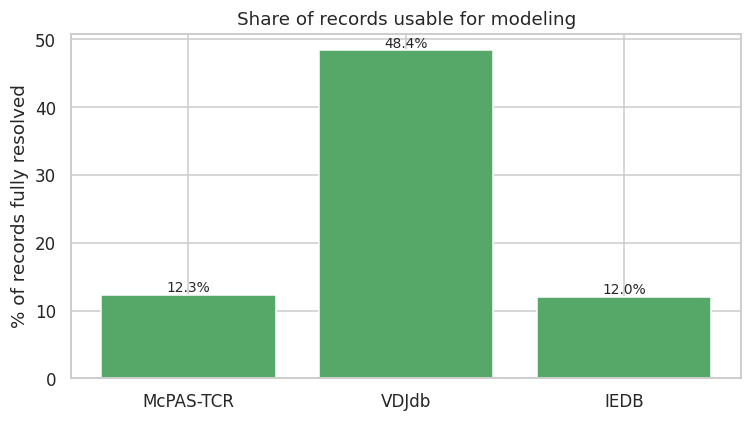

Total fully-resolved TCR–pMHC records across all three datasets: 134,269


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summ.index, summ["pct_fully_resolved"], color="#55A868")
ax.set_ylabel("% of records fully resolved"); ax.set_title("Share of records usable for modeling")
for i, v in enumerate(summ["pct_fully_resolved"]):
    ax.text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)
fig.tight_layout(); plt.show()

print(f"Total fully-resolved TCR–pMHC records across all three datasets: {int(summ['fully_resolved'].sum()):,}")
